In [1]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from scaleagdata_vito.presto.datasets import ScaleAgDataset
from scaleagdata_vito.presto.presto_df import load_dataset
from scaleagdata_vito.presto.utils import train_test_val_split, finetune_on_task, load_finetuned_model, evaluate_finetuned_model, get_pretrained_model_url

In [2]:
# Dataset Parameters
composite_window="dekad"
unique_id_column="Field_ID"
old_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_05112025/polygons/{composite_window}/"
new_data_folder=f"/vitodata/worldcereal/data/GEOMaize/extractions_14012026/polygons/{composite_window}/"

In [3]:
ref_id = 'Maize_2021_5mbuffered'
extractions_2021 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2021-07-01", "2021-12-01"],
)
ref_id = 'Maize_2022_5mbuffered'
extractions_2022 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2022-07-01", "2022-12-01"],
)
ref_id = 'Maize_2023_5mbuffered'
extractions_2023 = load_dataset(
    str(Path(old_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2023-07-01", "2023-12-01"],
)
ref_id = 'tamale_30field_2025_5mbuffer_2025-01-01_2025-12-31_30PYR'
extractions_2025 = load_dataset(
    str(Path(new_data_folder) / f'ref_id={ref_id}'),
    composite_window=composite_window,
    required_min_timesteps=10,
    window_of_interest=["2025-07-01", "2025-12-01"],
)


  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:744: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["start_date"] = window_of_interest[0]
/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/presto/presto_df.py:745: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["end_date"] = window_of_interest[1]
  0%|          | 0/1 [00:00<?, ?it/s]/data/users/Private/giorgia/git/scaleag-vito/src/scaleagdata_vito/

In [4]:
# Print min and max of yield distribution for each year
th = 6000
extractions_2022 = extractions_2022[extractions_2022['Yield kg/H'] < th].reset_index(drop=True)
datasets = [extractions_2021, extractions_2022, extractions_2023, extractions_2025]
years = [2021, 2022, 2023, 2025]

for i, (dataset, year) in enumerate(zip(datasets, years)):
    min_yield = dataset['Yield kg/H'].min()
    max_yield = dataset['Yield kg/H'].max()
    print(f"Year {year}: Min = {min_yield:.2f} kg/H, Max = {max_yield:.2f} kg/H")


Year 2021: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2022: Min = 226.60 kg/H, Max = 4792.60 kg/H
Year 2023: Min = 190.70 kg/H, Max = 3446.10 kg/H
Year 2025: Min = 785.55 kg/H, Max = 2830.45 kg/H


In [5]:
for y in years:
    datasets[years.index(y)]['year'] = y
extractions = pd.concat(datasets, ignore_index=True)
target_column = "Yield kg/H"

In [6]:
extractions["Field_ID_year"] = extractions['Field_ID'] + "_" + extractions['year'].astype(str)
extractions['REGION'] = extractions['REGION'].apply(lambda x: 'Northern' if x != 'Savanna' else 'Savanna')
extractions['DISTRICT'] = extractions['DISTRICT'].apply(lambda x: x.split('\n')[0].upper())
extractions['COMMUNITY'] = extractions['COMMUNITY'].apply(lambda x: x.upper())

In [7]:
import matplotlib.pyplot as plt

def plot_distribution(train_df, test_df, val_df, target_column):
    # Create a figure with subplots for the value counts including train/test/val splits
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Distribution of Variables by Train/Test/Validation Split', fontsize=16)

    # Define colors for train/test/val
    colors = ['blue', 'orange', 'green']
    labels = ['Train', 'Test', 'Val']
    datasets = [train_df, test_df, val_df]

    # REGION distribution
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        region_counts = data.REGION.value_counts()
        axes[0, 0].bar(region_counts.index, region_counts.values, alpha=0.7, color=color, label=label)
    axes[0, 0].set_title('REGION')
    axes[0, 0].set_xlabel('Region')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].legend()

    # COMMUNITY distribution
    all_communities = pd.concat(datasets).COMMUNITY.unique()
    x_pos = range(len(all_communities))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        community_counts = data.COMMUNITY.value_counts().reindex(all_communities, fill_value=0)
        axes[0, 1].bar([x + i*0.25 for x in x_pos], community_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[0, 1].set_title('COMMUNITY')
    axes[0, 1].set_xlabel('Community')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_xticks([x + 0.25 for x in x_pos])
    axes[0, 1].set_xticklabels(all_communities, rotation=45, ha='right')
    axes[0, 1].legend()

    # DISTRICT distribution
    all_districts = pd.concat(datasets).DISTRICT.unique()
    x_pos_district = range(len(all_districts))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        district_counts = data.DISTRICT.value_counts().reindex(all_districts, fill_value=0)
        axes[1, 0].bar([x + i*0.25 for x in x_pos_district], district_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 0].set_title('DISTRICT')
    axes[1, 0].set_xlabel('District')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_xticks([x + 0.25 for x in x_pos_district])
    axes[1, 0].set_xticklabels(all_districts, rotation=45, ha='right')
    axes[1, 0].legend()

    # YEAR distribution
    all_years = sorted(pd.concat(datasets).year.unique())
    x_pos_year = range(len(all_years))
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        year_counts = data.year.value_counts().reindex(all_years, fill_value=0)
        axes[1, 1].bar([x + i*0.25 for x in x_pos_year], year_counts.values, width=0.25, alpha=0.7, color=color, label=label)
    axes[1, 1].set_title('YEAR')
    axes[1, 1].set_xlabel('Year')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_xticks([x + 0.25 for x in x_pos_year])
    axes[1, 1].set_xticklabels(all_years)
    axes[1, 1].legend()

    # Yield kg/H histogram
    for i, (data, color, label) in enumerate(zip(datasets, colors, labels)):
        axes[0, 2].hist(data[target_column].dropna(), alpha=0.7, bins=20, color=color, label=label)
    axes[0, 2].set_title('Yield kg/H')
    axes[0, 2].set_xlabel('Yield kg/H')
    axes[0, 2].set_ylabel('Frequency')
    axes[0, 2].legend()

    # Remove the empty subplot
    axes[1, 2].remove()

    plt.tight_layout()
    plt.show()

2026-02-03 11:11:21.412 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:397 - Training set size: 130
2026-02-03 11:11:21.413 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:398 - Validation set size: 16
2026-02-03 11:11:21.414 | INFO     | scaleagdata_vito.presto.utils:train_test_val_split:399 - Test set size: 16


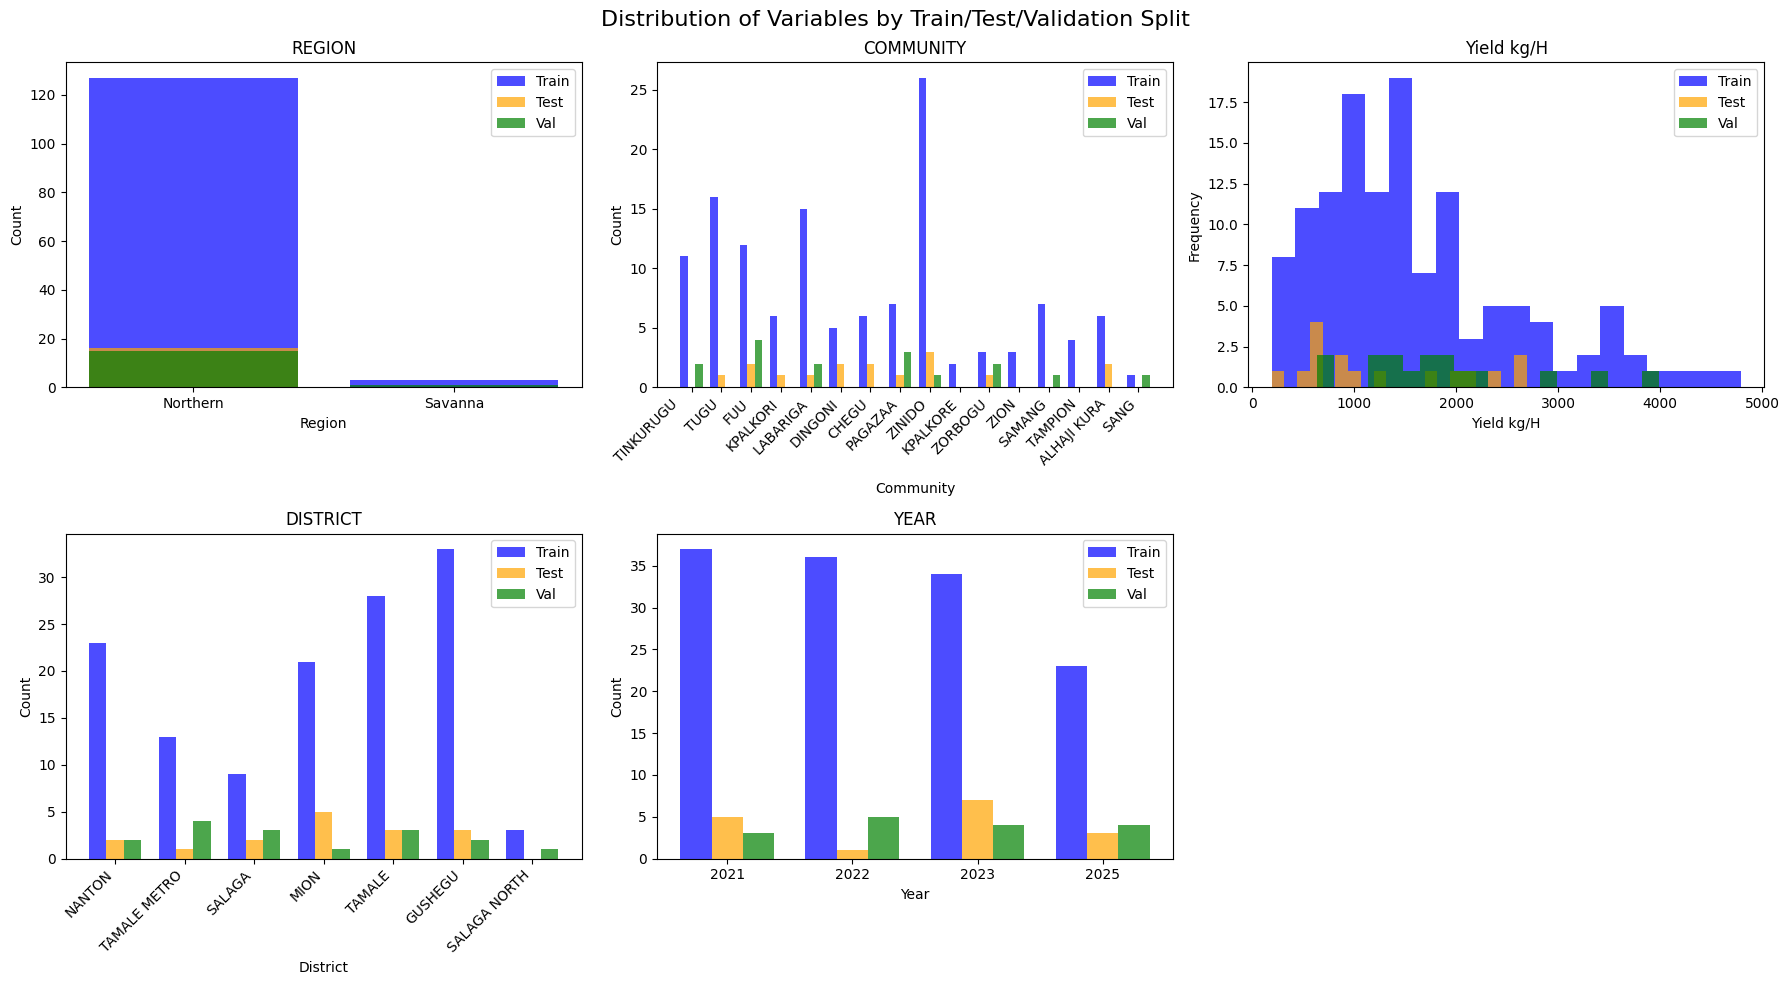

In [8]:
train_df, test_df, val_df = train_test_val_split(
    extractions,
    uniform_sample_by=unique_id_column,
    sampling_frac=0.8,
    nmin_per_class=1, # do not change this parameter
)
plot_distribution(train_df, test_df, val_df, target_column)

### Random Forest

In [9]:
s2_cols = [col for col in extractions.columns if 'OPTICAL' in col]
s1_cols = [col for col in extractions.columns if 'SAR' in col]
dem_cols = [col for col in extractions.columns if 'DEM' in col]
meteo_cols = [col for col in extractions.columns if 'METEO' in col]
feature_columns = s2_cols + s1_cols + dem_cols + meteo_cols

In [10]:
X_train, y_train = train_df[feature_columns], train_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]
X_val, y_val = val_df[feature_columns], val_df[target_column]
X_test, y_test = test_df[feature_columns], test_df[target_column]

In [11]:
import numpy as np 

X_train = X_train.replace(65535, np.nan)
X_val = X_val.replace(65535, np.nan)
X_test = X_test.replace(65535, np.nan)

R2_score on Train: 0.833843485094329
R2_score on Val: -0.5629687882799086
R2_score on Test: 0.2810531239600328


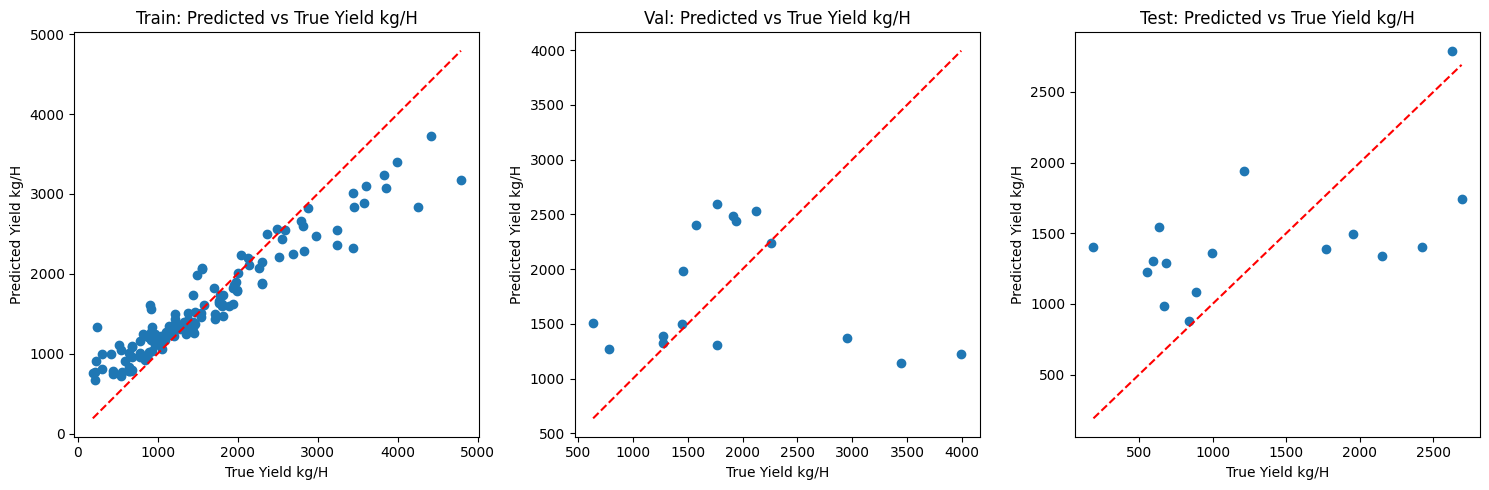

In [57]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipe = Pipeline([
    # median is a strong default for remote sensing; add_indicator keeps missingness info
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("rf", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    ))
])

rf_pipe.fit(X_train, y_train)
print("R2_score on Train:", rf_pipe.score(X_train, y_train))
print("R2_score on Val:", rf_pipe.score(X_val, y_val))
print("R2_score on Test:", rf_pipe.score(X_test, y_test))

preds_train = rf_pipe.predict(X_train)
preds_val = rf_pipe.predict(X_val)
preds_test = rf_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Train plot
axes[0].scatter(y_train, preds_train)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel("True Yield kg/H")
axes[0].set_ylabel("Predicted Yield kg/H")
axes[0].set_title("Train: Predicted vs True Yield kg/H")

# Validation plot
axes[1].scatter(y_val, preds_val)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel("True Yield kg/H")
axes[1].set_ylabel("Predicted Yield kg/H")
axes[1].set_title("Val: Predicted vs True Yield kg/H")

# Test plot
axes[2].scatter(y_test, preds_test)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_xlabel("True Yield kg/H")
axes[2].set_ylabel("Predicted Yield kg/H")
axes[2].set_title("Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()

### Cartboost 

0:	learn: 961.7169210	total: 14.4ms	remaining: 14.4s
100:	learn: 183.9773708	total: 723ms	remaining: 6.44s
200:	learn: 28.5621475	total: 1.39s	remaining: 5.52s
300:	learn: 5.2027413	total: 2.25s	remaining: 5.23s
400:	learn: 1.0231810	total: 3.09s	remaining: 4.62s
500:	learn: 0.1931485	total: 3.69s	remaining: 3.68s
600:	learn: 0.0404329	total: 4.32s	remaining: 2.87s
700:	learn: 0.0076149	total: 4.87s	remaining: 2.08s
800:	learn: 0.0014993	total: 5.43s	remaining: 1.35s
900:	learn: 0.0003121	total: 6s	remaining: 660ms
999:	learn: 0.0000677	total: 6.58s	remaining: 0us
R2_score on Train: 0.9999999999999936
R2_score on Val: -0.21738940231338288
R2_score on Test: 0.20484444313692118


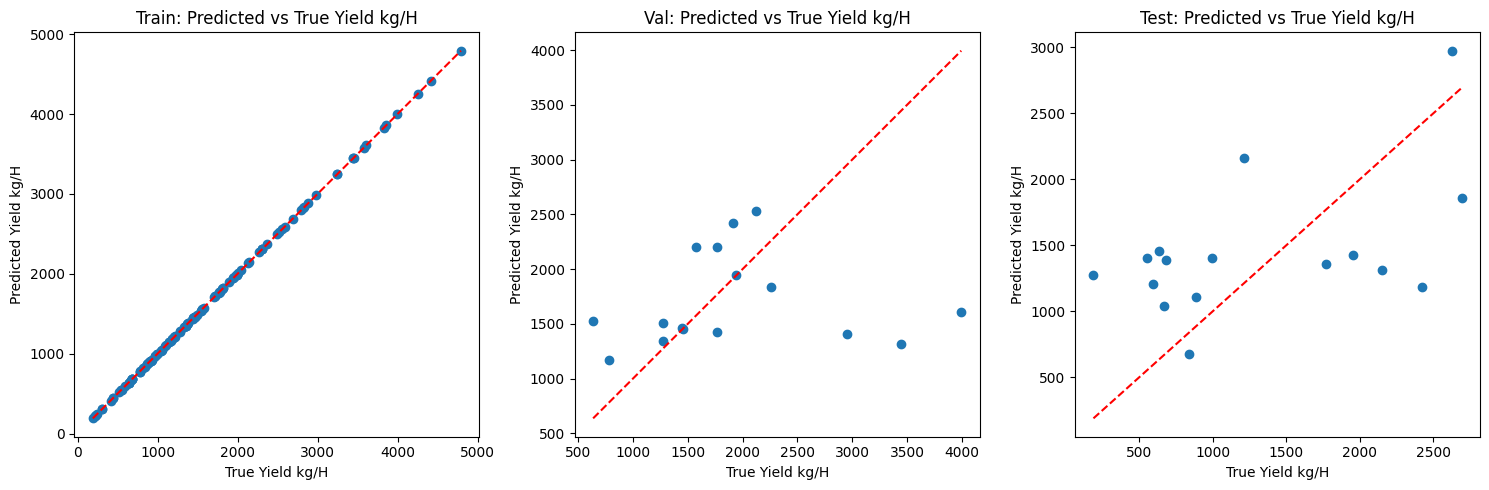

In [58]:
from catboost import CatBoostRegressor
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=100
    ))
])

cat_pipe.fit(X_train, y_train)
print("R2_score on Train:", cat_pipe.score(X_train, y_train))
print("R2_score on Val:", cat_pipe.score(X_val, y_val))
print("R2_score on Test:", cat_pipe.score(X_test, y_test))

preds_train = cat_pipe.predict(X_train) 
preds_val = cat_pipe.predict(X_val)
preds_test = cat_pipe.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Train plot
axes[0].scatter(y_train, preds_train)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
axes[0].set_xlabel("True Yield kg/H")
axes[0].set_ylabel("Predicted Yield kg/H")
axes[0].set_title("Train: Predicted vs True Yield kg/H")

# Validation plot
axes[1].scatter(y_val, preds_val)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
axes[1].set_xlabel("True Yield kg/H")
axes[1].set_ylabel("Predicted Yield kg/H")
axes[1].set_title("Val: Predicted vs True Yield kg/H")

# Test plot
axes[2].scatter(y_test, preds_test)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[2].set_xlabel("True Yield kg/H")
axes[2].set_ylabel("Predicted Yield kg/H")
axes[2].set_title("Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()

### Presto

In [59]:
from scaleagdata_vito.presto.datasets import ScaleAgDataset

In [60]:
num_timesteps = extractions.available_timesteps.max()
num_outputs = 1
composite_window = "dekad"
task_type = "regression"
target_name="Yield kg/H"
target_mean = train_df[target_name].mean()
target_std = train_df[target_name].std()   

In [61]:
train_ds = ScaleAgDataset(
    dataframe=train_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

val_ds = ScaleAgDataset(
    dataframe=val_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

test_ds = ScaleAgDataset(
    dataframe=test_df,
    num_timesteps=num_timesteps,
    num_outputs=num_outputs,
    task_type=task_type,
    target_name=target_name,
    composite_window=composite_window,
    target_mean=target_mean,
    target_std=target_std,
)

In [62]:
from torch.utils.data import DataLoader
from torch import nn
from torch.optim import AdamW, lr_scheduler
from prometheo.finetune import Hyperparams
from prometheo.models.presto import param_groups_lrd
from prometheo.models.presto.wrapper import (
    PretrainedPrestoWrapper,
    load_presto_weights,
)
from prometheo.predictors import collate_fn
from prometheo import finetune

# Set model Hyperparameters
models_dir = Path("/home/giorgia/Private/data/geomaize/models/")
experiment_name = "presto-ss-wc-10D-ft-dek-geomaize-comp"
model_output_dir = models_dir / experiment_name
model_output_dir.mkdir(parents=True, exist_ok=True)

batch_size = 32  # Back to original batch size
num_workers = 0
max_epochs = 50  # Keep reasonable number of epochs
patience = 15  # More patience for convergence
freeze_layers = ['encoder']
unfreeze_epoch = 10  # Keep early unfreezing

In [63]:
loss_fn = nn.MSELoss()
pretrained_model_path = get_pretrained_model_url(composite_window=composite_window)
try:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
    )
    model = load_presto_weights(model, pretrained_model_path, strict=False)
except Exception:
    model = PretrainedPrestoWrapper(
        num_outputs=num_outputs,
        regression=True,
        pretrained_model_path=pretrained_model_path,
    )

end_lr = 1e-5
start_lr = 1e-2
drop_factor = end_lr / start_lr
parameters = param_groups_lrd(model)
optimizer = AdamW(parameters, lr=start_lr)
for group in optimizer.param_groups:
    group["initial_lr"] = start_lr

hyperparams = Hyperparams(
    max_epochs=max_epochs,
    batch_size=batch_size,
    patience=patience,
    num_workers=num_workers,
    lr=start_lr,
)

scheduler_head = lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=unfreeze_epoch)
scheduler_warmup = lr_scheduler.LinearLR(optimizer, start_factor=0.1 * drop_factor, end_factor=drop_factor, total_iters=3)
scheduler_final = lr_scheduler.LambdaLR(
                                optimizer,
                                lr_lambda=lambda step: drop_factor * (0.99**step),
                                )
scheduler = lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[scheduler_head, scheduler_warmup, scheduler_final],
    milestones=[unfreeze_epoch, unfreeze_epoch+3],
)

train_dl = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    collate_fn=collate_fn,
)
val_dl = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    collate_fn=collate_fn,
)

finetuned_model = finetune.run_finetuning(
    model=model,
    train_dl=train_dl,
    val_dl=val_dl,
    experiment_name=experiment_name,
    output_dir=model_output_dir,
    loss_fn=loss_fn,
    optimizer=optimizer,
    scheduler=scheduler,
    hyperparams=hyperparams,
    setup_logging=False,  # Already setup logging
    freeze_layers=freeze_layers,
    unfreeze_epoch=unfreeze_epoch,
)

2026-02-03 11:55:52.850 | INFO     | prometheo.finetune:_setup:223 - Using output dir: /data/users/Private/giorgia/data/geomaize/models/presto-ss-wc-10D-ft-dek-geomaize-comp
2026-02-03 11:55:52.852 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.pos_embed
2026-02-03 11:55:52.852 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.weight
2026-02-03 11:55:52.853 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S1.bias
2026-02-03 11:55:52.853 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.weight
2026-02-03 11:55:52.854 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_RGB.bias
2026-02-03 11:55:52.854 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder.eo_patch_embed.S2_Red_Edge.weight
2026-02-03 11:55:52.855 | INFO     | prometheo.finetune:_train_loop:80 - Freezing layer: encoder

Finetuning:   0%|          | 0/50 [00:00<?, ?it/s]

Training:   0%|          | 0/5 [00:00<?, ?it/s]

2026-02-03 11:55:53.165 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 1/50: Epoch 1/50 | Train Loss: 1.4287 | Val Loss: 1.3761 | Best Loss: 1.3761 (improved)


Training:   0%|          | 0/5 [00:00<?, ?it/s]

...

2026-02-03 11:55:58.701 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 15/50: Epoch 15/50 | Train Loss: 0.9886 | Val Loss: 0.8829 | Best Loss: 0.8033 (no improvement for 13 epochs)


Training:   0%|          | 0/5 [00:00<?, ?it/s]

2026-02-03 11:55:59.146 | INFO     | prometheo.finetune:_train_loop:178 - PROGRESS after Epoch 16/50: Epoch 16/50 | Train Loss: 0.8851 | Val Loss: 0.8920 | Best Loss: 0.8033 (no improvement for 14 epochs)


Training:   0%|          | 0/5 [00:00<?, ?it/s]

2026-02-03 11:55:59.566 | INFO     | prometheo.finetune:_train_loop:161 - Early stopping!
2026-02-03 11:55:59.608 | INFO     | prometheo.finetune:run_finetuning:327 - Finetuning done


2026-02-03 11:56:06.078 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task
2026-02-03 11:56:06.112 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 1.6758, 'MSE': 1218046.75, 'R2_score': -0.8902, 'RMSE': 1103.6516}


2026-02-03 11:56:06.342 | INFO     | scaleagdata_vito.presto.utils:evaluate_finetuned_model:118 - Evaluating the finetuned model on regression task


{'MAPE': 1.2111, 'MSE': 1212347.875, 'R2_score': -0.2491, 'RMSE': 1101.0667}
{'MAPE': 0.5069, 'MSE': 785676.125, 'R2_score': -0.0285, 'RMSE': 886.3837}


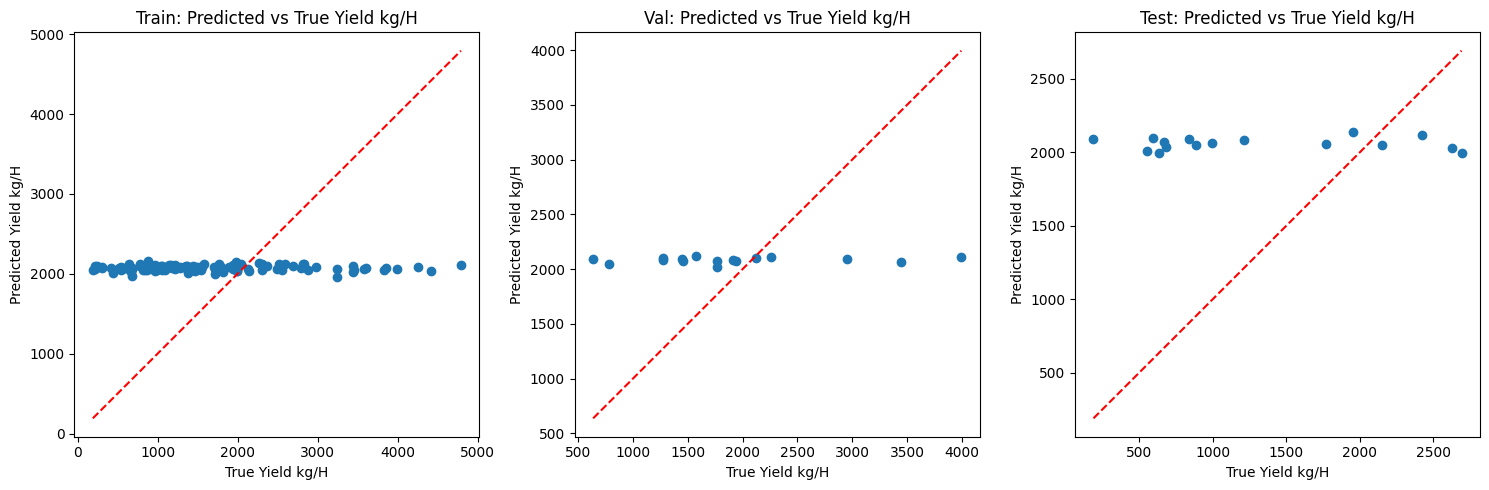

In [64]:
metrics, preds, targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=test_ds,
    batch_size=32,
    num_workers=0,
)

# Get predictions for train and validation sets as well
train_metrics, train_preds, train_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=train_ds,
    batch_size=32,
    num_workers=0,
)

val_metrics, val_preds, val_targets = evaluate_finetuned_model(
    finetuned_model,
    test_ds=val_ds,
    batch_size=32,
    num_workers=0,
)

# Create figure with subplots for train, val, and test
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Train plot
axes[0].scatter(train_targets, train_preds)
axes[0].plot([train_targets.min(), train_targets.max()], [train_targets.min(), train_targets.max()], 'r--')
axes[0].set_xlabel("True Yield kg/H")
axes[0].set_ylabel("Predicted Yield kg/H")
axes[0].set_title("Train: Predicted vs True Yield kg/H")

# Validation plot
axes[1].scatter(val_targets, val_preds)
axes[1].plot([val_targets.min(), val_targets.max()], [val_targets.min(), val_targets.max()], 'r--')
axes[1].set_xlabel("True Yield kg/H")
axes[1].set_ylabel("Predicted Yield kg/H")
axes[1].set_title("Val: Predicted vs True Yield kg/H")

# Test plot
axes[2].scatter(targets, preds)
axes[2].plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'r--')
axes[2].set_xlabel("True Yield kg/H")
axes[2].set_ylabel("Predicted Yield kg/H")
axes[2].set_title("Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()

### Presto + Catboost 

0:	learn: 0.9744180	total: 10.4ms	remaining: 10.3s
100:	learn: 0.1631830	total: 346ms	remaining: 3.08s
200:	learn: 0.0283599	total: 686ms	remaining: 2.73s
300:	learn: 0.0051663	total: 1.03s	remaining: 2.38s
400:	learn: 0.0009296	total: 1.44s	remaining: 2.15s
500:	learn: 0.0001738	total: 1.75s	remaining: 1.75s
600:	learn: 0.0000350	total: 2.06s	remaining: 1.37s
700:	learn: 0.0000064	total: 2.36s	remaining: 1.01s
800:	learn: 0.0000014	total: 2.68s	remaining: 666ms
900:	learn: 0.0000003	total: 2.98s	remaining: 328ms
999:	learn: 0.0000001	total: 3.24s	remaining: 0us
R2_score on Train: 0.9999999999999961
R2_score on Val: -0.03323211232017398
R2_score on Test: 0.19206481671492914


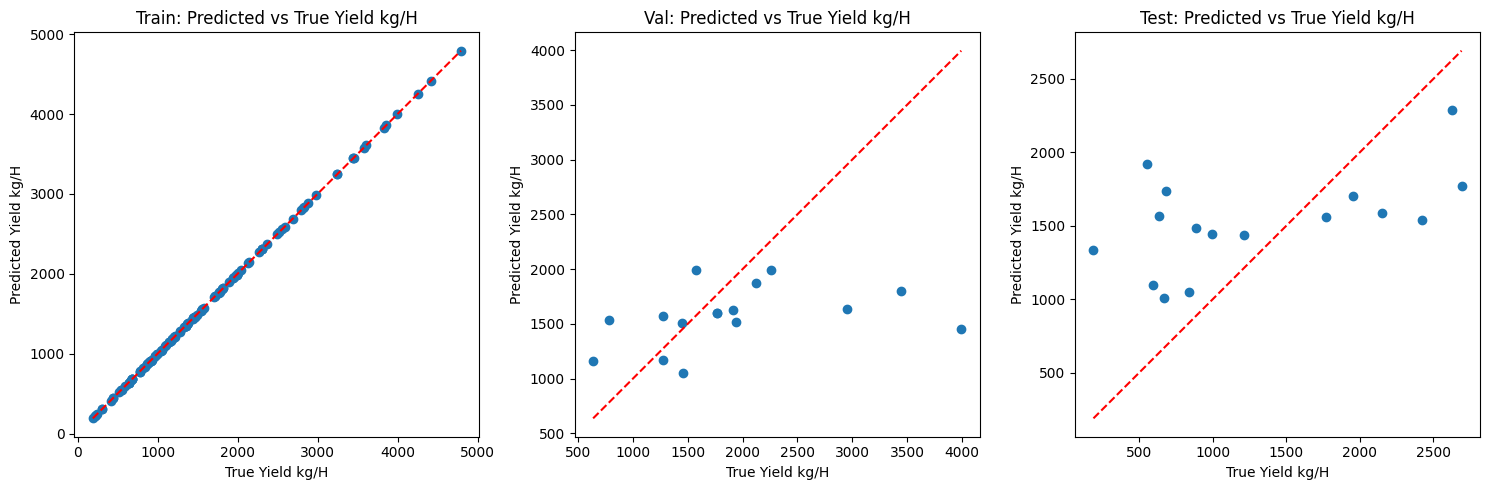

In [65]:
from scaleagdata_vito.presto.utils import get_encodings
model = PretrainedPrestoWrapper(
    num_outputs=num_outputs,
    regression=True,
)
model = load_presto_weights(model, pretrained_model_path, strict=False)

from torch.utils.data import DataLoader

all_encodings, all_targets = get_encodings(
    DataLoader(
        train_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ), 
    model)

all_encodings_val, all_targets_val = get_encodings(
    DataLoader(
        val_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model
)

all_encodings_test, all_targets_test = get_encodings(
    DataLoader(
        test_ds,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
    ),
    model   
)

cat_enc_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("cat", CatBoostRegressor(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        random_seed=42,
        loss_function='RMSE',
        verbose=100
    ))
])

cat_enc_pipe.fit(all_encodings, all_targets)
print("R2_score on Train:", cat_enc_pipe.score(all_encodings, all_targets))
print("R2_score on Val:", cat_enc_pipe.score(all_encodings_val, all_targets_val))
print("R2_score on Test:", cat_enc_pipe.score(all_encodings_test, all_targets_test))

preds_train = cat_enc_pipe.predict(all_encodings)
preds_val = cat_enc_pipe.predict(all_encodings_val)
preds_test = cat_enc_pipe.predict(all_encodings_test)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

preds_train = train_ds.revert_to_original_units(preds_train)
preds_val = val_ds.revert_to_original_units(preds_val)
preds_test = test_ds.revert_to_original_units(preds_test)
all_targets = train_ds.revert_to_original_units(all_targets)
all_targets_val = val_ds.revert_to_original_units(all_targets_val)
all_targets_test = test_ds.revert_to_original_units(all_targets_test)
# Train plot
axes[0].scatter(all_targets, preds_train)
axes[0].plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()], 'r--')
axes[0].set_xlabel("True Yield kg/H")
axes[0].set_ylabel("Predicted Yield kg/H")
axes[0].set_title("Train: Predicted vs True Yield kg/H")

# Validation plot
axes[1].scatter(all_targets_val, preds_val)
axes[1].plot([all_targets_val.min(), all_targets_val.max()], [all_targets_val.min(), all_targets_val.max()], 'r--')
axes[1].set_xlabel("True Yield kg/H")
axes[1].set_ylabel("Predicted Yield kg/H")
axes[1].set_title("Val: Predicted vs True Yield kg/H")

# Test plot
axes[2].scatter(all_targets_test, preds_test)
axes[2].plot([all_targets_test.min(), all_targets_test.max()], [all_targets_test.min(), all_targets_test.max()], 'r--')
axes[2].set_xlabel("True Yield kg/H")
axes[2].set_ylabel("Predicted Yield kg/H")
axes[2].set_title("Test: Predicted vs True Yield kg/H")

plt.tight_layout()
plt.show()